In [1]:
from scoresbibm.tasks import get_task

In [2]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom

from functools import partial

import haiku as hk

import matplotlib.pyplot as plt

from probjax.core import rv

import optax

from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss
from probjax.distributions.sde import VESDE
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Independent, Empirical
from probjax.utils.odeint import _odeint

In [3]:
def drift_lotka_volterra(t, data, alpha,beta, gamma, delta):
    predator, prey = data
    # predator and prey are swapped
    d_predator = alpha * predator - beta * predator * prey
    d_prey = -gamma * prey + delta * predator * prey
    return d_predator, d_prey

In [4]:
dt = 0.1
time_start = 0. 
time_end = 20.
eval_time_points = int(20 / dt)
ts = jnp.linspace(time_start, time_end, eval_time_points)

In [5]:
def model(key, ode_method="rk4", ode_ts_grid=ts):
    key_theta0, key_theta1, key_theta2, key_theta3, key_predator, key_prey = jrandom.split(key, 6)
    prior = TransformedDistribution(Normal(jnp.zeros(1), jnp.ones(1)), lambda x: jax.nn.sigmoid(x)*2 + 1.)
    theta0 = rv(prior, name="theta0")(key_theta0)
    theta1 = rv(prior, name="theta1")(key_theta1)
    theta2 = rv(prior, name="theta2")(key_theta2)
    theta3 = rv(prior, name="theta3")(key_theta3)
    
    predator, prey = _odeint(drift_lotka_volterra, (1., 0.5), ode_ts_grid, theta0, theta1, theta2, theta3, method=ode_method)

    
    x0 = rv(Independent(Normal(predator, 0.1),1), name="x0")(key_predator)
    x1 = rv(Independent(Normal(prey, 0.1),1), name="x1")(key_prey)
    
    thetas = jnp.concatenate([theta0, theta1, theta2, theta3], axis=0)
    xs = jnp.concatenate([x0, x1], axis=0)
    return thetas, xs 


In [6]:
thetas, xs = jax.vmap(model)(jax.random.split(jax.random.PRNGKey(0), 10000))

In [7]:
xs.shape

(10000, 400)

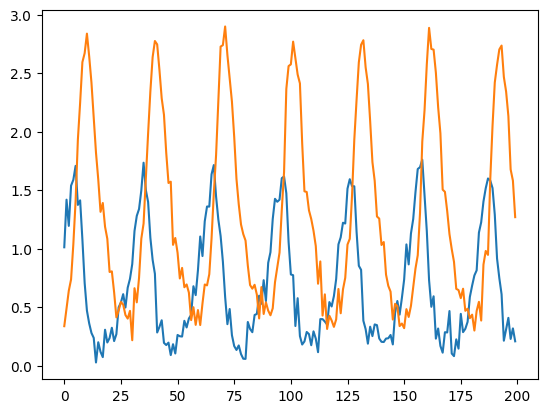

In [8]:
plt.plot(xs[0][:200])
plt.plot(xs[0][200:])

In [33]:

# VESDE 
T = 1.
T_min = 1e-5
sigma_min = 0.01
sigma_max = 15.

p0 = Independent(Empirical(thetas), 1) # Empirical distribution of the data
sde = VESDE(p0, sigma_min=sigma_min , sigma_max=sigma_max)

def output_scale_fn(t, x):
    scale = sde.marginal_stddev(t, jnp.ones_like(x))
    return (1/scale * x).reshape(x.shape)

In [34]:
# s(theta| x_t, x_t+1)
# x_t R^2, x_t+1 R^2
hidden_dim = 50
activation = jax.nn.gelu
num_hidden = 4
layer_norm = False

def score_net(a, theta, x_t0, x_t1=None):
        context = x_t0 
        if x_t1 is not None:
            context = jnp.concatenate([context, x_t1], axis=-1)
        else:
            context = jnp.concatenate([context, jnp.zeros_like(context)], axis=-1)
    
        x = jnp.concatenate([theta, context], axis=-1)

        time_embedding = GaussianFourierEmbedding(hidden_dim)(a[..., None])
        h = activation(hk.Linear(hidden_dim)(x) + time_embedding)

        for _ in range(num_hidden - 1):
            h_new = hk.Linear(hidden_dim)(h)
            h_new += time_embedding
            h = activation(h_new)

            if layer_norm:
                h = hk.LayerNorm(axis=-1, create_scale=True, create_offset=True)(h)

        out = hk.Linear(theta.shape[-1])(h)
        out = output_scale_fn(a, out)
        return out


In [35]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones(10), thetas[:10], jnp.ones((10, 2)), x_t1=jnp.ones((10, 2))) # Initialize the parameters of the model

In [ ]:
d_predator = alpha * predator - beta * predator * prey
d_prey = -gamma * prey + delta * predator * prey

In [124]:
def generate_step(key):
    key_batch, key_x0, key_x1, n0, n1 = jax.random.split(key, 5)
    idx = jax.random.choice(key_batch, thetas.shape[0], (), replace=False)
    
    theta = thetas[idx]
    prey_t0 = jax.random.uniform(key_x0, (2,), minval=0., maxval=10.)
    predator_t0 = jax.random.uniform(key_x1, (2,), minval=0., maxval=10.)
    
    dprey_t1, dpredator_t1 = drift_lotka_volterra(0., (prey_t0, predator_t0), theta[0], theta[1], theta[2], theta[3])
    prey_t1 = prey_t0 + dprey_t1 * dt   + jax.random.normal(n0, (2,)) * 0.1
    predator_t1 = predator_t0 + dpredator_t1 * dt + jax.random.normal(n1, (2,)) * 0.1
    
    x_t0 = jnp.concatenate([prey_t0, predator_t0], axis=0)
    x_t1 = jnp.concatenate([prey_t1, predator_t1], axis=0)
    
    return theta, x_t0, x_t1

def generate_data(key, n):
    keys = jax.random.split(key, n)
    return jax.vmap(generate_step)(keys)

In [126]:
theta_batch, x_t0, x_t1 = generate_data(jax.random.PRNGKey(0), 10)

In [127]:
key = jax.random.PRNGKey(0)
init_fn, model_fn = hk.without_apply_rng(hk.transform(score_net)) # Init function initializes the parameters of the model, model_fn is the actual model function (which takes the parameters as first argument, hence is a "pure function")
params = init_fn(key, jnp.ones(10),theta_batch, x_t0, x_t1) # Initialize the parameters of the model

In [128]:
model_fn(params, jnp.ones(10), theta_batch, x_t0, x_t1)

Array([[-0.09 ,  0.02 ,  0.018, -0.004],
       [-0.042,  0.025,  0.015, -0.002],
       [-0.03 ,  0.013, -0.003, -0.008],
       [-0.061,  0.034,  0.012, -0.024],
       [-0.034,  0.003, -0.026,  0.012],
       [-0.064,  0.048,  0.001,  0.029],
       [-0.074,  0.023,  0.003,  0.008],
       [-0.072,  0.04 ,  0.001, -0.027],
       [-0.066,  0.032,  0.02 , -0.006],
       [-0.053,  0.017, -0.001,  0.005]], dtype=float32)

In [129]:
def weight_fn(t):
    return jnp.clip(sde.diffusion(t, jnp.ones((1,1,1)))**2, 1e-4)

def loss_fn(params, key, batch_size= 32):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data and random times
    times = jax.random.uniform(rng_time, (batch_size, 1), minval=T_min, maxval=1.0)
    theta_batch, x_t0, x_t1 = generate_data(rng_data, batch_size) # n, T_max, 1
    

    # Forward diffusion, do not perturb conditioned data
    loss = denoising_score_matching_loss(params, rng_sample, times, theta_batch, None, model_fn= model_fn, mean_fn=sde.marginal_mean, std_fn = sde.marginal_stddev, weight_fn=weight_fn, x_t0=x_t0, x_t1=x_t1)
    
    return loss


In [130]:
@partial(jax.pmap, axis_name="num_devices")
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    
    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [131]:
schedule = optax.linear_schedule(1e-3, 0, 500*10, 500*10)
optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adam(schedule))
opt_state = optimizer.init(params)

In [132]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [133]:
key = jrandom.PRNGKey(0)
for _ in range(50):
    l = 0
    for i in range(500):
        key, subkey = jrandom.split(key)
        loss, replicated_params, replicated_opt_state = update(replicated_params, jax.random.split(subkey, (n_devices,)), replicated_opt_state)
        l += loss[0] /500
    print(l)
params = jax.tree_map(lambda x: x[0], replicated_params)

4912126.0
4889834.0
4834952.5
4682646.5
4915561.0
4532721.0
4626879.0
4816696.0
4916312.5
4500034.5
4814866.5
4760065.0
4769650.5
4570010.0
4914871.5
4621791.0
4591934.0
4660133.5
4664019.0
5009368.0
4872193.0
4850880.0
4630850.0
4866162.0
4817949.0
4578583.0
4718503.0
4797140.0
4518893.5
4861277.5
4559573.0
4649092.5
4647260.5
4729792.5
4607504.5
4777305.0
4535849.0
4582423.5
4637989.5
4674077.5
4511425.5
4772224.5
4590246.0
4667546.0
4643447.5
4431664.0
4853946.0
4435778.5
4844877.0
4577817.0


In [85]:
x_o = xs[0, :]

In [101]:
x = x_o.reshape(-1, 2)
x_past = x[:-1]
x_future = x[1:]

In [103]:
x1_marg = x[1:]

In [107]:
increment_scores = model_fn(params, jnp.ones(1), jnp.ones((199, 4)), x_past, x_future)
marginal_scores = model_fn(params, jnp.ones(1), jnp.ones((199, 4)), x1_marg)

In [136]:
increment_scores.sum(0) - marginal_scores.sum(0)

Array([-4.474,  2.295, -4.722,  0.535], dtype=float32)

In [137]:
x_past = x[:-1]
x_future = x[1:]
theta = theta[None, :]
theta, x_past, x_future = jnp.broadcast_arrays(theta, x_past, x_future)
increment_scores = model_fn(params, t, theta, x_past, x_future)
marginal_scores = model_fn(params, t, theta, x1_marg)

score = increment_scores.sum(0) - marginal_scores.sum(0)


NameError: name 'theta' is not defined

In [109]:
marginal_scores.shape

(199, 4)

In [ ]:
from functools import partial
from probjax.utils.sdeint import sdeint


# Reverse SDE drift
def drift_backward(t, theta, x_o):
    x = x_o.reshape(-1, 2)

    x_past = x[:-1]
    x_future = x[1:]
    theta = theta[None, :]
    theta, x_past, x_future = jnp.broadcast_arrays(theta, x_past, x_future)
    increment_scores = model_fn(params, t, theta, x_past, x_future)
    marginal_scores = model_fn(params, t, theta, x1_marg)
    
    score = increment_scores.sum(0) - marginal_scores.sum(0)

    score = score.reshape(x.shape)

    f =  sde.drift(t,x) - sde.diffusion(t,theta)**2 * score
    if replace_conditioned:
        f = f * (1-condition_mask[:len(node_ids)])
    
    return f

# Reverse SDE diffusion
def diffusion_backward(t,x, node_ids=node_ids,condition_mask=condition_mask, replace_conditioned=True):
    #t = T - t
    b =  sde.diffusion(t,x) 
    if replace_conditioned:
        b = b * (1-condition_mask[:len(node_ids)])
    return b